## Control System Examples

* Root Locus
* Nyquist
* Frequency Response
    * Magnitude
    * Phase
* State Space System
    * Step Response
    * Impulse Response

In [1]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
#from scipy.signal import TransferFunction, lsim
#from scipy.integrate import odeint

Define the system 
$$
G(s)H(s) = \frac{k(s+3)}{s (s^2 + 2 s + 5)}
$$

#### First Root Locus
Couple of YouTube videos on Root Locus in Python<br>
[Python Help - Root Locus (rlocus)](https://www.youtube.com/watch?v=u2H4lpqjEBo) <br>
and <br>
[Python Help - 3rd Order Root Locus (Animation)](https://www.youtube.com/watch?v=UPt1OnjyBps)


/home/cgreco/src/Python/Control/.venv/lib/python3.12/site-packages/control/rlocus.py:210: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


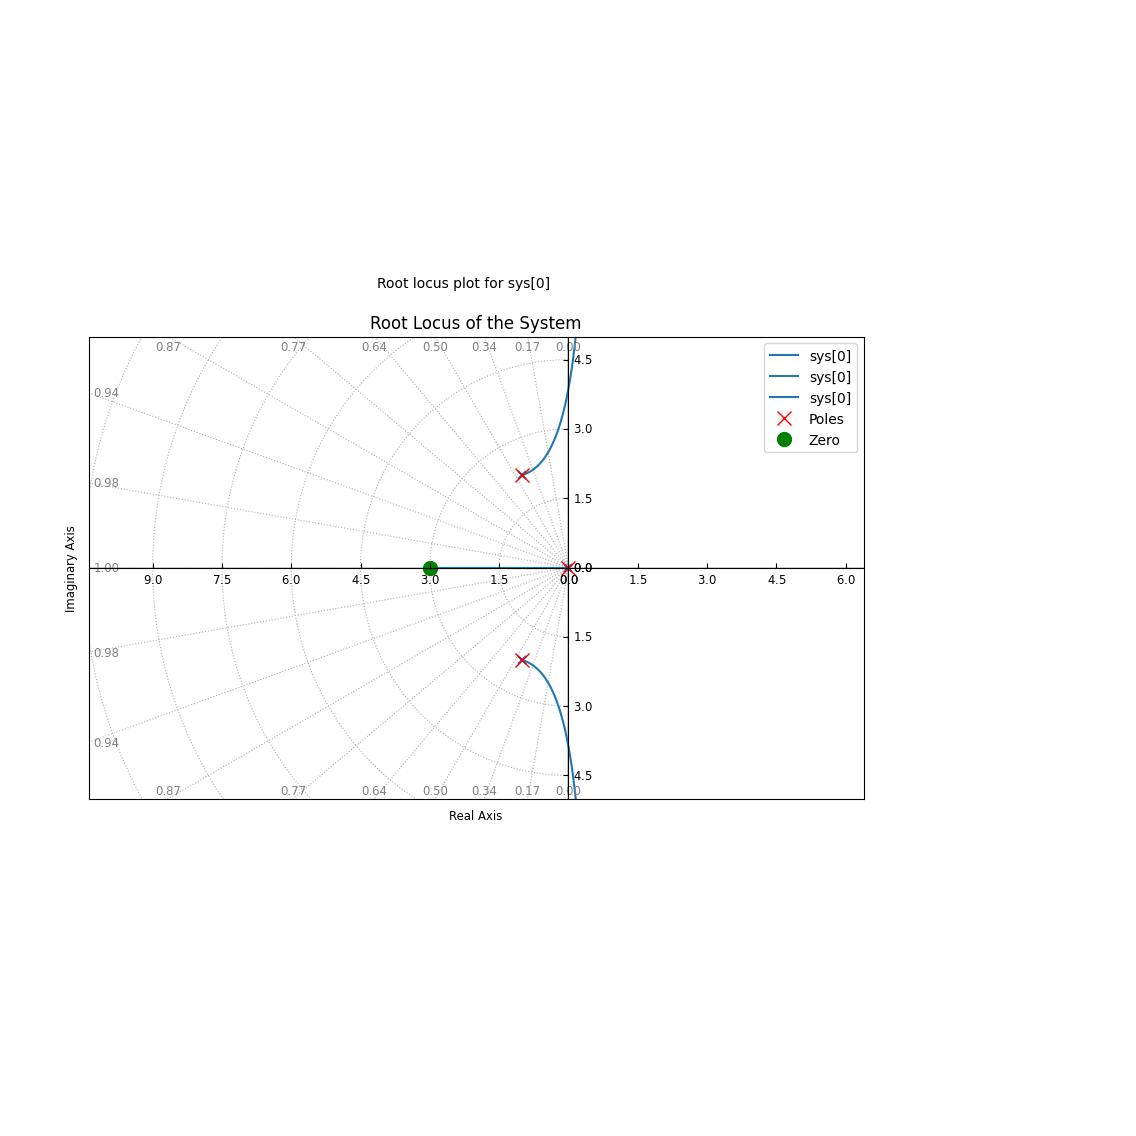

In [2]:
num = [1, 3]  # Coefficients of (s + 3)
den = [1, 2, 5, 0]  # Coefficients of s^3 + 2s^2 + 5s
#num = [1]
#den = [1, 2, 1]  # Represents s^2 + 2s + 1


# Define the transfer function
#sys = ctrl.TransferFunction(num, den)
sys = ctrl.tf(num, den)

# Plot the root locus
plt.figure(figsize=(10, 6))
rlist, klist = ctrl.root_locus(sys, plot=True)

# Plot poles and zeros
plt.plot(np.real([-1 + 2j, -1 - 2j, 0]), np.imag([-1 + 2j, -1 - 2j, 0]), 'rx', label='Poles', markersize=10, linewidth=2)
plt.plot(-3, 0, 'go', label='Zero', markersize=10, linewidth=2)

# Plot settings
plt.title('Root Locus of the System')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True)
plt.legend()
plt.xlim(-6, 2)
plt.ylim(-5, 5)

plt.show()


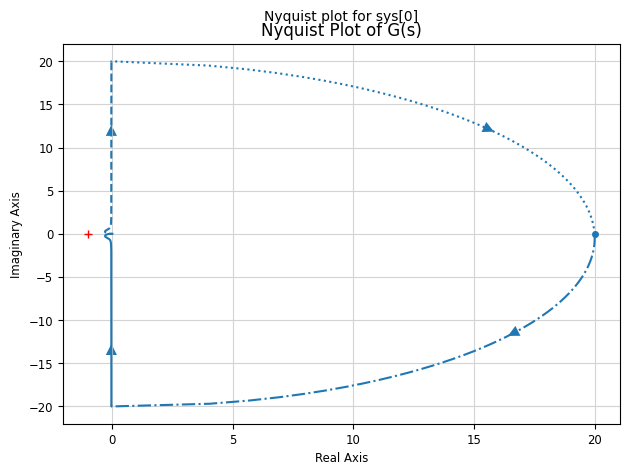

In [3]:
# Define the transfer function
#num = [1]
#den = [1, 2, 1]  # Represents s^2 + 2s + 1
#sys = ctrl.tf(num, den)

# Generate the Nyquist plot
ctrl.nyquist_plot(sys)
plt.title('Nyquist Plot of G(s)')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid(True)
plt.show()

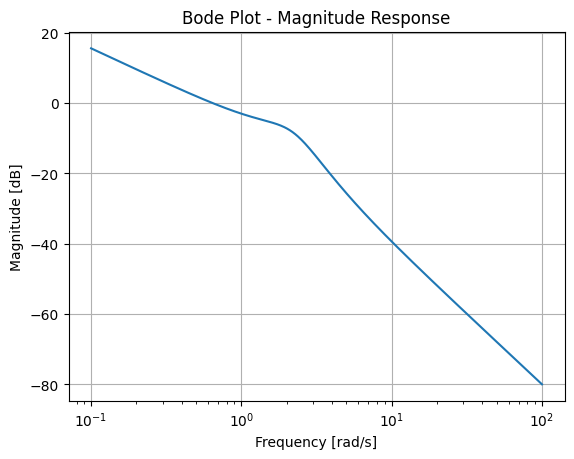

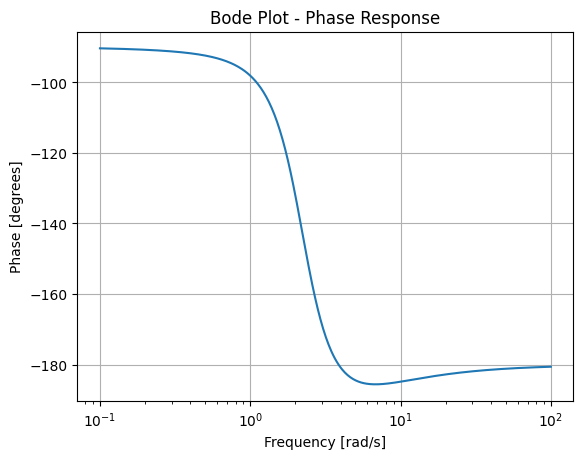

In [4]:
# Create the transfer function
#system = signal.TransferFunction(num, den)
sys = signal.lti(num, den)

# Generate frequency points
w = np.logspace(-1, 2, 500)

# Calculate the frequency response
w, mag, phase = signal.bode(sys, w=w)

# Plot the magnitude response
plt.figure()
plt.semilogx(w, mag)
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.title('Bode Plot - Magnitude Response')
plt.grid(True)
plt.show()

# Plot the phase response
plt.figure()
plt.semilogx(w, phase)
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Phase [degrees]')
plt.title('Bode Plot - Phase Response')
plt.grid(True)
plt.show()

### State Space System

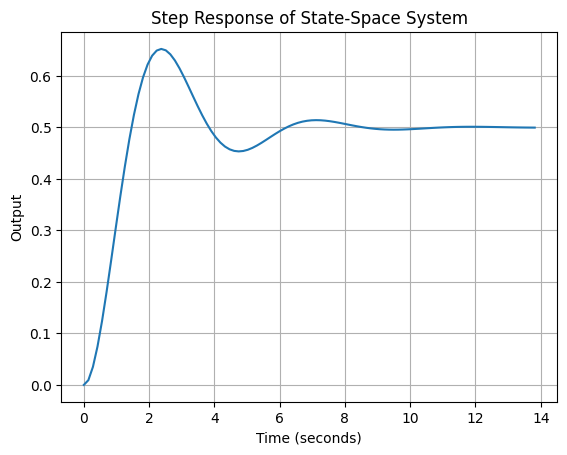

In [5]:
A = np.array([[-1,-2],[1,0]])
#A = np.array([[-2,-1],[1,0]])
B = np.array([[1], [0]])
C = np.array([[0, 1]])
D = np.array([[0]])

# Create the state-space system
sys = ctrl.ss(A, B, C, D)


# Calculate the step response
T, yout = ctrl.step_response(sys)

# Plot the step response
plt.plot(T, yout)
plt.xlabel("Time (seconds)")
plt.ylabel("Output")
plt.title("Step Response of State-Space System")
plt.grid(True)
plt.show()


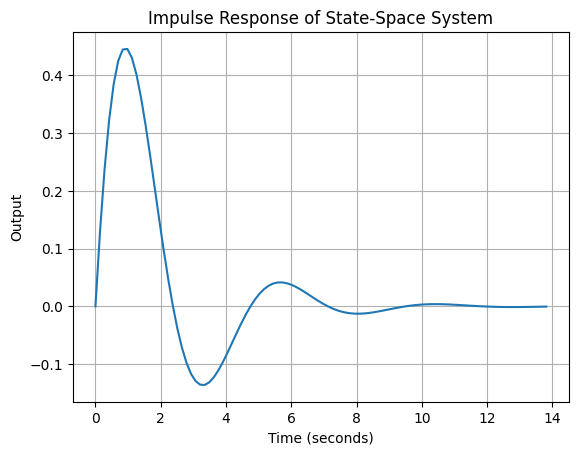

In [6]:
T, yout = ctrl.impulse_response(sys)

# Plot the impulse response
plt.plot(T, yout)
plt.xlabel("Time (seconds)")
plt.ylabel("Output")
plt.title("Impulse Response of State-Space System")
plt.grid(True)
plt.show()


In [13]:
# Calculate controllability matrix
ctrb_matrix = ctrl.ctrb(sys.A, sys.B)
rank_ctrb = np.linalg.matrix_rank(ctrb_matrix)
print("Controllability Matrix:")
print(ctrb_matrix)
print("Rank of Controllability Matrix:", rank_ctrb)
# Check if the system is controllable
if rank_ctrb == sys.A.shape[0]:
    print("The system is controllable.")
else:
    print("The system is not controllable.")
# Calculate observability matrix
obsv_matrix = ctrl.obsv(sys.A, sys.C)
rank_obsv = np.linalg.matrix_rank(obsv_matrix)
print("\nObservability Matrix:")
print(obsv_matrix)
print("Rank of Observability Matrix:", rank_obsv)
# Check if the system is observable
if rank_obsv == sys.A.shape[0]:
    print("The system is observable.")
else:
    print("The system is not observable.")
# Calculate the eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(sys.A)
print("\nEigenvalues:")
print(eigenvalues)
print("Eigenvectors:")
print(eigenvectors)
# Calculate the poles of the system
poles = np.linalg.eigvals(sys.A)
print("\nPoles of the system:")
print(poles)
# Calculate the zeros of the system
zeros = np.linalg.eigvals(sys.A)
print("Zeros of the system:")
print(zeros)
# Calculate the gain matrix
gain_matrix = np.linalg.inv(sys.C @ np.linalg.inv(sys.A) @ sys.B)
print("Gain Matrix:")
print(gain_matrix)


Controllability Matrix:
[[ 1. -1.]
 [ 0.  1.]]
Rank of Controllability Matrix: 2
The system is controllable.

Observability Matrix:
[[0. 1.]
 [1. 0.]]
Rank of Observability Matrix: 2
The system is observable.

Eigenvalues:
[-0.5+1.32287566j -0.5-1.32287566j]
Eigenvectors:
[[ 0.81649658+0.j          0.81649658-0.j        ]
 [-0.20412415-0.54006172j -0.20412415+0.54006172j]]

Poles of the system:
[-0.5+1.32287566j -0.5-1.32287566j]
Zeros of the system:
[-0.5+1.32287566j -0.5-1.32287566j]
Gain Matrix:
[[-2.]]
